# Лабораторна робота №3
Цей зошит було відрефакторено та адаптовано для запуску на **MacOS (Apple Silicon M1/M2/M3)**. 

У ньому реалізовано пайплайн обробки даних: зменшення розмірності, кластеризація, навчання автокодувальника, балансування даних (аугментація) та порівняльний аналіз класифікаторів (опціональне завдання).

```bash
pip install tensorflow==2.19.0 tensorflow-metal==1.2.0
```

### Крок 1: Імпорт необхідних бібліотек
Тут ми завантажуємо всі інструменти, які знадобляться для роботи: `sklearn` для машинного навчання, `tensorflow` для нейромережі (автокодувальника) та `imblearn` для балансування класів.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Бібліотеки для машинного навчання та кластеризації
from sklearn import model_selection, decomposition
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Бібліотеки для автокодувальника
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

# Бібліотеки для балансування класів
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

import warnings
warnings.filterwarnings('ignore')

### Крок 2: Завантаження даних
Зчитуємо файл `shaped.pickle`. У результаті ми отримуємо матрицю `ab`, яка містить 297 зразків, кожен з яких має 1200 ознак.

In [2]:
with open('data/shaped.pickle', 'rb') as f:
    ab = pickle.load(f)

print(f"Розмірність оригінальних даних: {ab.shape}")

Розмірність оригінальних даних: (297, 1200)


### Крок 3: Зменшення розмірності (SVD)
Оскільки 1200 ознак — це дуже багато (може викликати перенавчання або дуже довгі обчислення), ми стискаємо їх до **10 найважливіших ознак** за допомогою алгоритму `TruncatedSVD`.

In [3]:
svd = decomposition.TruncatedSVD(n_components=10)
X_embedded = svd.fit_transform(ab)

print(f"Розмірність даних після SVD стиснення: {X_embedded.shape}")

Розмірність даних після SVD стиснення: (297, 10)


### Крок 4: Кластеризація (MiniBatchKMeans)
Розбиваємо наші дані на 4 групи (кластери) алгоритмом `MiniBatchKMeans`. Результат записуємо у `y_pred` (це будуть наші мітки класів). Далі будуємо графік, використовуючи перші 2 з 10 ознак для візуалізації.

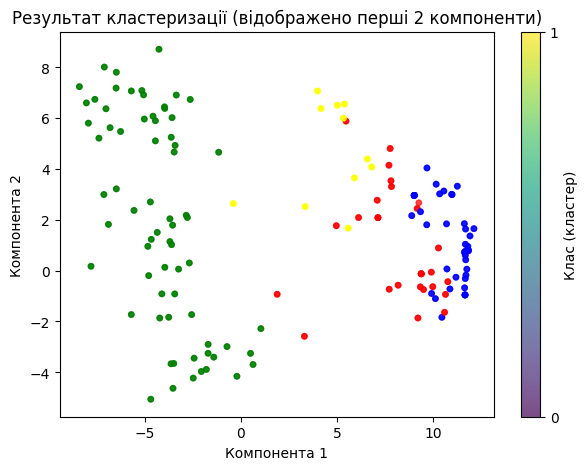

In [4]:
kmeans = MiniBatchKMeans(n_clusters=4, random_state=42, n_init="auto")
y_pred = kmeans.fit_predict(X_embedded)

colors = np.array(['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'black', 'magenta', 'cyan', 'brown'])

plt.figure(figsize=(7, 5))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=15, c=colors[y_pred], alpha=0.7)
plt.title("Результат кластеризації (відображено перші 2 компоненти)")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.colorbar(ticks=[0, 1, 2, 3], label="Клас (кластер)")
plt.show()

### Крок 5: Навчання Автокодувальника (Autoencoder)
Автокодувальник — це нейромережа, яка вчиться стискати дані, а потім відновлювати їх з мінімальними втратами. Наш стискає 10 ознак до 2, а потім розширює назад до 10. 

In [5]:
# Створюємо архітектуру нейромережі
model = Sequential([
    Input(shape=(10,)),
    Dense(2, activation='relu'),   # Кодер: стискає до 2 нейронів
    Dense(10, activation='linear') # Декодер: відновлює до 10 нейронів
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Запускаємо навчання. Дивись на час ms/step!
history = model.fit(X_embedded, X_embedded, epochs=500, batch_size=32, verbose=1)

2026-04-02 18:03:31.248267: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-02 18:03:31.248517: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-02 18:03:31.248534: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1775142211.248714 6169422 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1775142211.249946 6169422 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │            22 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52 (208.00 B)

 Trainable params: 52 (208.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500


2026-04-02 18:03:32.586436: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 22.7510
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21.8390
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 20.9998
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 20.1872
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19.4929
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.8315
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.2148
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17.6466
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 17.1148
Epoch 10/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.6186
Epoch 11/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 16.1615
Epoch 12/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15.7277
Epoch 13/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15.3085
Epoch 14/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14.9359
Epoch 15/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14.57

### Крок 6: Аугментація (Балансування) даних
Часто кластери бувають нерівномірними (в одному 100 елементів, в іншому 10). Щоб моделі краще навчалися, класи штучно вирівнюють. Ми генеруємо нові зразки за допомогою алгоритмів `RandomOverSampler`, `SMOTE` та `ADASYN`.

Кількість елементів у класах ДО балансування:
{np.int32(0): np.int64(55), np.int32(1): np.int64(138), np.int32(2): np.int64(82), np.int32(3): np.int64(22)}

Кількість елементів у класах ПІСЛЯ балансування (на прикладі SMOTE):
{np.int32(0): np.int64(138), np.int32(1): np.int64(138), np.int32(2): np.int64(138), np.int32(3): np.int64(138)}


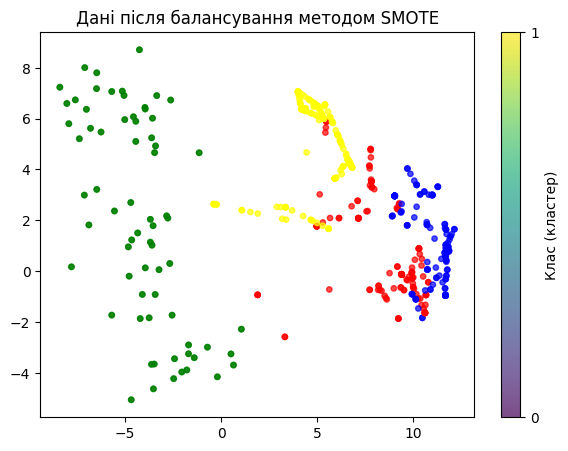

In [6]:
print("Кількість елементів у класах ДО балансування:")
unique, counts = np.unique(y_pred, return_counts=True)
print(dict(zip(unique, counts)))

# 1. RandomOverSampler (просте дублювання)
ros = RandomOverSampler(random_state=42)
X_resampled1, y_resampled1 = ros.fit_resample(X_embedded, y_pred)

# 2. SMOTE (створення синтетичних зразків сусідів)
smote = SMOTE(random_state=42)
X_resampled2, y_resampled2 = smote.fit_resample(X_embedded, y_pred)

# 3. ADASYN (адаптивне створення синтетичних зразків)
adasyn = ADASYN(random_state=42)
X_resampled3, y_resampled3 = adasyn.fit_resample(X_embedded, y_pred)

print("\nКількість елементів у класах ПІСЛЯ балансування (на прикладі SMOTE):")
unique_res, counts_res = np.unique(y_resampled2, return_counts=True)
print(dict(zip(unique_res, counts_res)))

# Візуалізуємо збалансовані дані SMOTE
plt.figure(figsize=(7, 5))
plt.scatter(X_resampled2[:, 0], X_resampled2[:, 1], s=15, c=colors[y_resampled2], alpha=0.7)
plt.title("Дані після балансування методом SMOTE")
plt.colorbar(ticks=[0, 1, 2, 3], label="Клас (кластер)")
plt.show()

### Крок 7: ОПЦІОНАЛЬНЕ ЗАВДАННЯ
Згідно із завданням, тут ми використовуємо алгоритм класифікації (`Random Forest`), щоб спробувати передбачити, до якого класу належить зразок.
Ми навчаємо дві моделі:
1. На **оригінальних** даних (де класів різна кількість).
2. На **збалансованих** даних (згенерованих через SMOTE).

В кінці будуємо матриці помилок для порівняння. Скріншоти результатів з цього блоку можна вставити у звіт як виконання додаткового завдання.

--- Результати класифікації БЕЗ аугментації (Оригінальні дані) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      1.00      0.97        30
           2       1.00      1.00      1.00        12
           3       1.00      0.50      0.67         4

    accuracy                           0.97        60
   macro avg       0.98      0.88      0.91        60
weighted avg       0.97      0.97      0.96        60

--- Результати класифікації З аугментацією (SMOTE) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        33
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        30

    accuracy                           1.00       111
   macro avg       1.00      1.00      1.00       111
weighted avg       1.00      1.00      1.00       111



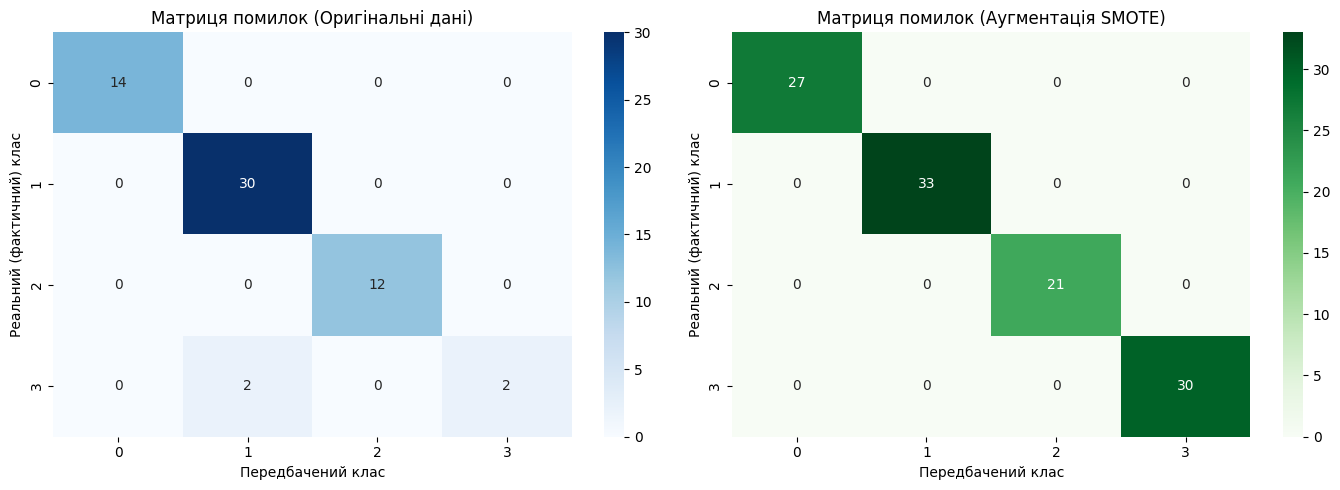

In [7]:
# ==================================================================
# 1. Навчання класифікатора на ОРИГІНАЛЬНИХ (незбалансованих) даних
# ==================================================================
train_x, valid_x, train_y, valid_y = model_selection.train_test_split(X_embedded, y_pred, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(train_x, train_y)
y_pred_rf = rf_model.predict(valid_x)

print("--- Результати класифікації БЕЗ аугментації (Оригінальні дані) ---")
print(classification_report(valid_y, y_pred_rf))

# ==================================================================
# 2. Навчання класифікатора на ЗБАЛАНСОВАНИХ (SMOTE) даних
# ==================================================================
train_x_smote, valid_x_smote, train_y_smote, valid_y_smote = model_selection.train_test_split(X_resampled2, y_resampled2, test_size=0.2, random_state=42)

rf_model_smote = RandomForestClassifier(random_state=42)
rf_model_smote.fit(train_x_smote, train_y_smote)
y_pred_smote = rf_model_smote.predict(valid_x_smote)

print("--- Результати класифікації З аугментацією (SMOTE) ---")
print(classification_report(valid_y_smote, y_pred_smote))

# ==================================================================
# Порівняння результатів через Матрицю помилок (Confusion Matrix)
# ==================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Матриця для оригінальних даних
sns.heatmap(confusion_matrix(valid_y, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Матриця помилок (Оригінальні дані)')
axes[0].set_ylabel('Реальний (фактичний) клас')
axes[0].set_xlabel('Передбачений клас')

# Матриця для збалансованих даних
sns.heatmap(confusion_matrix(valid_y_smote, y_pred_smote), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Матриця помилок (Аугментація SMOTE)')
axes[1].set_ylabel('Реальний (фактичний) клас')
axes[1].set_xlabel('Передбачений клас')

plt.tight_layout()
plt.show()